# 23 — Does more source diversity help repaired Experiment 0?

This notebook inspects the **source-learning-curve-v1** development study. It does
not fit models or encode videos. A learning curve compares the same held-out
recordings while the training set grows by whole recordings. More clips from one
recording are useful examples, but they are not more independent sources.

Read [the protocol](../../../../../docs/studies/future-innovation/source-learning-curve-protocol.md)
and [execution guide](../../../../../slurm/future-innovation/SOURCE_LEARNING_CURVE.md). New runs use the
[available-cohort amendment](../../../../../docs/studies/future-innovation/source-learning-curve-available-cohort-protocol.md);
the saved configuration below identifies the policy for this run. The repaired
50-clip STOP remains a completed historical result. Missing expanded processing
is an execution state and is not another negative scientific result.

In [1]:
from pathlib import Path
import json
import hashlib
import os
import pandas as pd
from IPython.display import display
ROOT = Path(os.environ.get("GAVD6_ROOT", Path.cwd())).expanduser().resolve()
while not (ROOT / "src/gavd6_sjepa").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RUN = Path(os.environ.get("FI_RUN_ROOT", ROOT / "outputs/future-innovation-source-curve-dev-20260911-v2")).expanduser()
RUN = (ROOT / RUN).resolve() if not RUN.is_absolute() else RUN.resolve()
if not RUN.is_dir():
    raise FileNotFoundError(f"Study directory does not exist: {RUN}")
print("Study root:", RUN)
print("Protocol: source-learning-curve-v1; development data")
print("Inspection only: saved values and file presence; no fitting or numerical verification.")
if (RUN / "config/study.json").exists():
    study = json.loads((RUN / "config/study.json").read_text())
    print("Frozen run ID:", study.get("run_id", "not recorded"))
    print("Synthetic study:", study.get("synthetic", "not recorded"))
    print("Cohort policy:", study.get("cohort_policy", "historical strict development-media policy"))
def read(relative):
    return json.loads((RUN / relative).read_text())
def file_hash(relative):
    path = RUN / relative
    return hashlib.sha256(path.read_bytes()).hexdigest() if path.is_file() else None


Study root: /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/future-innovation/learning-curve
Protocol: source-learning-curve-v1; development data
Inspection only: saved values and file presence; no fitting or numerical verification.
Frozen run ID: learning-curve
Synthetic study: False
Cohort policy: available-development-v1


## 1. Establish the denominator before counting examples

The full annotation manifest, the original candidate list, verified pose windows,
and cached teacher arrays count different things. A clip excluded because the
old 50-window cap was reached has not failed pose quality. Unknown participant
identity remains unknown; a video ID is not a participant ID.

Confirmation recordings are reserved before new pose extraction or teacher
encoding. All sequences from those recordings stay outside the development curve.
Prior experiment exposure is recorded conservatively from supplied manifests.

In [2]:
if (RUN / "reports/cohort-audit.json").exists():
    audit = read("reports/cohort-audit.json")
    print("Inventory at reservation time — verified counts here precede expanded processing:")
    display(pd.Series({k: audit[k] for k in ["annotated_sequences", "recordings", "parent_candidates", "verified_eligible_sequences", "explicitly_identified_participants", "total_participants"]}, dtype=object).to_frame("count"))
    display(pd.DataFrame(audit["reservation"]).T)
    print(audit["participant_status"])
else:
    print("No frozen expanded inventory is present locally.")
if (RUN / "config/availability-contract.json").exists():
    availability = read("config/availability-contract.json")
    print("Frozen available-cohort selection (file availability precedes pose eligibility):")
    display(pd.Series(availability["summary"], dtype=object).to_frame("saved value"))
    inventory = pd.read_csv(RUN / "config/media-availability.csv")
    omitted = inventory.loc[inventory.role.eq("development") & ~inventory.included]
    print("Unavailable development recordings excluded before processing:", len(omitted))
    display(omitted[["video_id", "annotated_sequences", "exclusion_reason"]])
    print("Confirmation roles and source folds were assigned before filtering and remain unchanged.")
    print("Only config/processing-sequences.csv and config/processing-videos.csv feed new candidate construction.")
if (RUN / "data/cohort-complete.json").exists():
    prepared = read("data/cohort-complete.json")
    print("Saved completed preparation:")
    display(pd.Series({k: prepared.get(k) for k in ["eligible_windows", "eligible_sources", "failed_pose_windows", "confirmation_processed"]}, dtype=object).to_frame("saved value"))
    windows = pd.read_csv(RUN / "data/manifests/development-windows.csv")
    display(windows.groupby("outer_fold").agg(clips=("window_id", "size"), recordings=("video_id", "nunique")))
    display(windows.groupby("evidence_origin").agg(clips=("window_id", "size"), recordings=("video_id", "nunique")))
else:
    print("Expanded pose eligibility has not been sealed. The initial verified count is not the expanded cohort size.")
if (RUN / "data/cache-complete.json").exists():
    cached = read("data/cache-complete.json")
    display(pd.Series({k: v for k, v in cached.items() if k != "artifacts"}, dtype=object).to_frame("saved cache evidence"))
else:
    print("Expanded teacher encoding has not completed. Existing gate-v2 arrays cover only their original windows.")


Inventory at reservation time — verified counts here precede expanded processing:


,count
annotated_sequences,1874
recordings,348
parent_candidates,1662
verified_eligible_sequences,50
explicitly_identified_participants,0
total_participants,None


,recordings,sequences
confirmation,43,176
development,305,1698


unknown; source IDs are not participant IDs
Frozen available-cohort selection (file availability precedes pose eligibility):


,saved value
available_recordings,334
cohort_policy,available-development-v1
included_annotated_sequences,1633
included_development_recordings,293
manifest_recordings,348
planned_development_recordings,305
reserved_confirmation_recordings,43
unavailable_development_recordings,12


...

Confirmation roles and source folds were assigned before filtering and remain unchanged.
Only config/processing-sequences.csv and config/processing-videos.csv feed new candidate construction.
Saved completed preparation:


,saved value
eligible_windows,1403
eligible_sources,290
failed_pose_windows,106
confirmation_processed,False


,clips,recordings
outer_fold,,
0,305,59
1,336,57
2,213,57
3,275,59
4,274,58


,clips,recordings
evidence_origin,,
new_processing,1353,287
parent_cache,50,43


,saved cache evidence
binding,d2fe43b5f40ec3cfb40687670b82b43760ada92ad4dbaa...
new_windows,1353
reused_windows,50


## 2. Compare increasing training subsets on fixed evaluation sources

Five outer folds keep recordings together. Within each outer training pool,
three independently ordered source lists provide nested prefixes near 40, 80,
and 160 sources. All eligible clips from each selected recording are included.
The all-sources endpoint is fitted once per fold. Three labels pointing to that
same endpoint are not repeated optimization evidence.

Each subset has its own three inner folds, input scaling, target scaling, and
penalty selection. The solved objective uses summed weighted loss. Setting
`lambda = number_of_training_windows * rho` keeps the penalty comparable when
the amount of training data changes. The fixed rho grid is
`[0.0025, 0.025, 0.25, 2.5, 25, 250]`.

In [3]:
if (RUN / "manifests/learning-plan.json").exists():
    plan = read("manifests/learning-plan.json")
    display(pd.DataFrame(plan["entries"]))
    print("Distinct fitted source subsets required:", len(plan["fits"]))
else:
    print("The final subset plan waits for expanded pose eligibility, cache completion, and teacher audits.")


,actual_sources,actual_windows,available_sources,fit_id,outer_fold,size,status,subset_seed
0,40,261,231,dfa8a285e58144a18c69c06a,0,40,planned,261201
1,80,524,231,193e7c6571c5b875710d2568,0,80,planned,261201
2,160,862,231,4a932d88561035341b6e3b73,0,160,planned,261201
3,231,1098,231,04e9f4394b02594f68360cde,0,all,planned,261201
4,40,195,231,c96079c21461aff7cbc57b71,0,40,planned,261202
5,80,362,231,4f3ca7f79b156d01960f4857,0,80,planned,261202
6,160,772,231,d257713b17f8858b2bc4706e,0,160,planned,261202
7,231,1098,231,04e9f4394b02594f68360cde,0,all,planned,261202
8,40,187,231,6f4e4d2ee962fddf71ea4414,0,40,planned,261203
9,80,415,231,c0c7ec62e8531a8d9f96208e,0,80,planned,261203


Distinct fitted source subsets required: 50


## 3. Read improvements against the right controls

Report the RGB reference and four arms: real history, four-frame block shuffle,
different-source mismatch within the current partition, and no skeleton retaining
joint validity. The primary skeleton comparison is real minus no skeleton.
Improvement over RGB by itself can include changes to RGB regularization.

Inputs use frames 0–31. Target frames 38–39 were encoded in the full 64-frame
video; the task predicts **contextual teacher features**. This scaling study
does not change that target or claim a pure coordinate-motion effect.

In [4]:
stages = ["data/cohort-complete.json", "data/cache-complete.json", "data/audit-complete.json", "manifests/plan-complete.json", "reports/complete.json"]
display(pd.DataFrame({"artifact": stages, "present_locally": [(RUN / p).is_file() for p in stages]}))
print("Presence is an inventory check. It does not assert integrity or numerical reconstruction.")
if (RUN / "manifests/learning-plan.json").exists():
    identities = read("manifests/learning-plan.json")["fits"]
    print("Selected-model completion receipts present:", sum((RUN / f"models/{i}/complete.json").is_file() for i in identities), "/", len(identities))
if (RUN / "data/logs/development-media.csv").exists():
    media = pd.read_csv(RUN / "data/logs/development-media.csv")
    if "role" in media:
        media = media.loc[media.role.eq("development")]
    unavailable = media.loc[~media.available]
    label = "Frozen availability exclusions" if (RUN / "config/availability-contract.json").exists() else "Last preparation media check: unavailable development recordings"
    print(label, "=", len(unavailable))
    if len(unavailable):
        display(unavailable[["video_id", "method", "reason"]])
attempts = [json.loads(p.read_text()) for p in sorted((RUN / "logs/stages").glob("*.json"))]
if attempts:
    display(pd.DataFrame(attempts).reindex(columns=["started_utc", "stage", "fold", "status", "returncode", "elapsed_seconds", "slurm_job_id", "log"]))
    for attempt in attempts:
        if attempt["status"] == "failed":
            print(f"Failed {attempt['stage']} attempt: {attempt['log']}")
            print(attempt.get("error", ""), attempt.get("output_tail", "")[-2000:])
else:
    print("No structured stage logs are present. Older runs may have ordinary Slurm logs only.")
print("A running record without a finish time may reflect an interrupted job; check Slurm. Old failures remain visible after retries.")


,artifact,present_locally
0,data/cohort-complete.json,True
1,data/cache-complete.json,True
2,data/audit-complete.json,True
3,manifests/plan-complete.json,True
4,reports/complete.json,True


Presence is an inventory check. It does not assert integrity or numerical reconstruction.
Selected-model completion receipts present: 50 / 50
Frozen availability exclusions = 12


,video_id,method,reason
37,5qM6wxZ_dNs,missing,Source video not found in declared storage: 5q...
105,IuEeKzqsfmk,missing,Source video not found in declared storage: Iu...
110,JSyLnt3rLxs,missing,Source video not found in declared storage: JS...
180,XYw9gQkQv_Y,missing,Source video not found in declared storage: XY...
187,YjRoLtP1di0,missing,Source video not found in declared storage: Yj...
241,gOMr8ezwiSU,missing,Source video not found in declared storage: gO...
243,gXws-A4op-E,missing,Source video not found in declared storage: gX...
261,jzkn287X-84,missing,Source video not found in declared storage: jz...
267,lSXuxyrywwY,missing,Source video not found in declared storage: lS...
310,sf5X4YYkWUA,missing,Source video not found in declared storage: sf...


,started_utc,stage,fold,status,returncode,elapsed_seconds,slurm_job_id,log
0,2026-09-12T23:48:02.428184+00:00,initialize,NaN,passed,0,135.131605,115304,logs/stages/20260912T234802Z-3b1e352c82dd-init...
1,2026-09-12T23:50:17.786733+00:00,prepare,NaN,passed,0,2575.284188,115305,logs/stages/20260912T235017Z-5a1376170207-prep...
2,2026-09-13T01:27:59.492891+00:00,cache,NaN,passed,0,2791.126940,115306,logs/stages/20260913T012759Z-4a09bd84f880-cach...
3,2026-09-13T02:14:31.296097+00:00,audit-teacher,NaN,passed,0,68.738176,115306,logs/stages/20260913T021431Z-2b2ba15e1c31-audi...
4,2026-09-13T02:15:40.111916+00:00,plan,NaN,passed,0,15.131654,115306,logs/stages/20260913T021540Z-02bda33ce795-plan...
5,2026-09-13T02:16:09.037633+00:00,run,1.0,passed,0,740.419060,115394,logs/stages/20260913T021609Z-219d4bd6453b-run-...
6,2026-09-13T02:16:09.037878+00:00,run,3.0,passed,0,736.295285,115396,logs/stages/20260913T021609Z-42f0351ae9f3-run-...
7,2026-09-13T02:16:09.038438+00:00,run,4.0,passed,0,728.858059,115307,logs/stages/20260913T021609Z-62a8a4ae45e0-run-...
8,2026-09-13T02:16:09.037055+00:00,run,0.0,passed,0,1891.419099,115393,logs/stages/20260913T021609Z-a31bf5662221-run-...
9,2026-09-13T02:16:09.037371+00:00,run,2.0,passed,0,769.050863,115395,logs/stages/20260913T021609Z-b861d431d5d1-run-...


A running record without a finish time may reflect an interrupted job; check Slurm. Old failures remain visible after retries.


## 4. Interpret the curve and its uncertainty

The declared predictive R² compares errors with the applicable outer-training
mean, never the held-out mean. Its denominator changes with training size, so
the report also includes raw teacher-unit squared error. Paired bootstrap draws
resample whole recording sources and retain multiplicity, aligned across sizes,
arms and subset repetitions. Their intervals condition on saved fitted models;
they do not include retraining or adaptive research choices.

A growing matched skeleton increment can motivate confirmation. Lower overall
error with a flat matched increment motivates a separate target or representation
study. The final decision uses the frozen largest-endpoint criteria; no notebook
launches confirmation or student training.

Saved status (not independently verified here): development_stop
Saved measurement_complete: True
Synthetic fixture: False
Result population: available-development-v1


,saved cohort
available_recordings,334
cohort_policy,available-development-v1
included_annotated_sequences,1633
included_development_recordings,293
manifest_recordings,348
planned_development_recordings,305
reserved_confirmation_recordings,43
unavailable_development_recordings,12


,arm,delta_r2,r2_baseline,r2_full,size
0,clip-mismatch,7.054447e-05,0.614752,0.614822,160
1,no-skeleton,-3.315038e-06,0.614752,0.614748,160
2,real-skeleton,-2.543749e-06,0.614752,0.614749,160
3,time-shuffle,6.135102e-06,0.614752,0.614758,160
4,clip-mismatch,-1.973498e-04,0.451045,0.450848,40
5,no-skeleton,-2.685651e-06,0.451045,0.451043,40
6,real-skeleton,-1.782267e-04,0.451045,0.450867,40
7,time-shuffle,-2.943652e-05,0.451045,0.451016,40
8,clip-mismatch,-2.754346e-05,0.540281,0.540254,80
9,no-skeleton,0.000000e+00,0.540281,0.540281,80


,ci95,contrast,estimate,positive_fraction,size
0,"[-0.00038544809464123353, 5.019695292994964e-06]",real_gain,-1.782267e-04,0.0280,40
1,"[-0.0003809343942618573, 7.644851096738613e-06]",matched_increment,-1.755411e-04,0.0305,40
2,"[-0.0003378101842966802, 1.9536180253745738e-05]",real_minus_shuffle,-1.487902e-04,0.0480,40
3,"[-3.534156546235271e-05, 4.26867046343445e-05]",real_gain,2.105396e-06,0.5405,80
4,"[-3.5341565462354565e-05, 4.268670463437873e-05]",matched_increment,2.105396e-06,0.5405,80
5,"[-1.9195585982978434e-05, 0.00012864653771753597]",real_minus_shuffle,4.405767e-05,0.8765,80
6,"[-6.689972049971811e-05, 6.608005458745938e-05]",real_gain,-2.543749e-06,0.4660,160
7,"[-6.02921710807891e-05, 6.509847458545656e-05]",matched_increment,7.712890e-07,0.5020,160
8,"[-6.899137062784111e-05, 5.365027297760387e-05]",real_minus_shuffle,-8.678851e-06,0.3955,160
9,"[4.1374454629170004e-05, 0.0006696855469790319]",real_gain,3.570991e-04,0.9855,all


,matched_increment,mismatch_gain,real_gain,real_minus_shuffle,size,subset_seed
0,0.000012,-0.000023,-3.402750e-07,0.000025,160,261201
1,0.000011,0.000234,1.289189e-05,-0.000031,160,261202
2,-0.000020,0.000000,-2.018287e-05,-0.000020,160,261203
3,-0.000044,0.000059,-5.203868e-05,0.000005,40,261201
4,-0.000025,0.000016,-2.509739e-05,0.000042,40,261202
5,-0.000458,-0.000667,-4.575441e-04,-0.000494,40,261203
6,0.000010,-0.000049,9.931631e-06,0.000094,80,261201
7,-0.000044,0.000000,-4.373967e-05,0.000026,80,261202
8,0.000040,-0.000033,4.012422e-05,0.000012,80,261203
9,0.000358,0.000603,3.570991e-04,0.000353,all,261201


Saved numerical-verification job succeeded for these study/plan/report bytes: 2026-09-13T02:55:53.729848+00:00
This notebook has not rechecked model or cache integrity. Use verify for a fresh reconstruction.


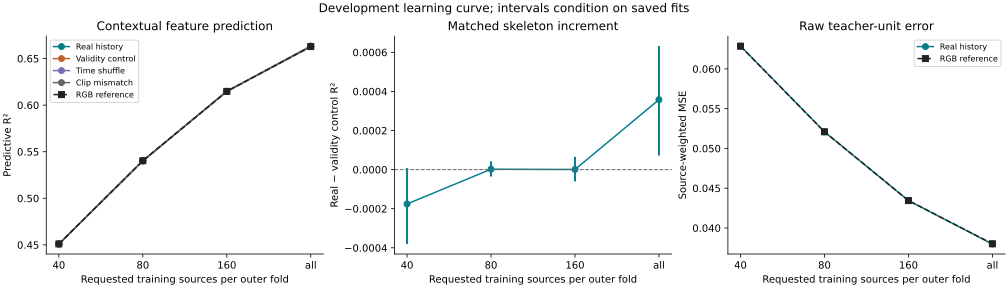

In [5]:
report_path = RUN / "reports/learning-curve.json"
if report_path.exists():
    result = read("reports/learning-curve.json")
    print("Saved status (not independently verified here):", result["status"])
    print("Saved measurement_complete:", result["measurement_complete"])
    print("Synthetic fixture:", result["synthetic"])
    if "cohort_availability" in result:
        print("Result population:", result["cohort_policy"])
        display(pd.Series(result["cohort_availability"], dtype=object).to_frame("saved cohort"))
    display(pd.DataFrame(result["arm_means"]))
    display(pd.DataFrame(result["contrasts"]))
    display(pd.DataFrame(result["per_subset_contrasts"]))
    current_binding = {p: file_hash(p) for p in ["config/study.json", "manifests/learning-plan.json", "reports/complete.json", "reports/learning-curve.json"]}
    verified = [a for a in attempts if a.get("stage") == "verify" and a.get("status") == "passed"
                and a.get("returncode") == 0 and all(current_binding.values())
                and a.get("binding_before") == current_binding and a.get("binding_after") == current_binding]
    if verified:
        print("Saved numerical-verification job succeeded for these study/plan/report bytes:", verified[-1]["finished_utc"])
        print("This notebook has not rechecked model or cache integrity. Use verify for a fresh reconstruction.")
    else:
        print("No successful numerical-verification log matches the current study/plan/report bytes.")
    from IPython.display import SVG, display
    if (RUN / "reports/learning-curve.svg").exists():
        display(SVG(filename=str(RUN / "reports/learning-curve.svg")))
else:
    print("No learning-curve report is present in the selected study; execution is incomplete.")


## 5. Verify or resume outside this inspection notebook

Use `bash slurm/future-innovation-scaling/launch/submit.sh status` with the same
`FI_RUN_ROOT` for a frozen-input integrity check and stage inventory. After
reporting, use the launcher’s `verify` command to reconstruct
selected coefficients, predictions and paired scores. That command performs CPU
verification fits but writes no scientific artifacts. Use the execution guide
for preparation, caching, Slurm submission and interrupted-stage recovery.